In [1]:
import pandas as pd
import numpy as np
import json
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from pytorch_lightning import seed_everything
import seaborn as sns
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed = 42
seed_everything(seed)

/home/teresa/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42


42

In [2]:
# load df from after feature selection
model_df = pd.read_csv("data/model_df.csv")

X = model_df.drop(columns=["AI_exposure"])
Y = model_df["AI_exposure"]

# 60/20/20 train/val/test split
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.25, random_state=42)

# load feature groups
with open("feature_groups.json", "r") as f:
    feature_groups = json.load(f)

# create a dictionary to store the models
models = {}

## Models

### Baseline: mean predictor
We establish the mean predictor baseline as a sanity check for the performance of our models. Any model should beat this baseline.

In [3]:
mean_pred = np.ones(len(Y_test)) * Y_train.mean()
baseline_mse = mean_squared_error(Y_test, mean_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(Y_test, mean_pred)
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline MAE: {baseline_mae:.4f}")

Baseline RMSE: 0.0249
Baseline MAE: 0.0195


## Linear Regression
We first train linear regression without regularization. Then, since we want to investigate which features contribute the most to the prediction, we train Lasso regression and intepret the sparse weight vector.

In [4]:
# linear regression
linear_model = LinearRegression()
linear_model.fit(X_train, Y_train)
linear_pred_train = linear_model.predict(X_train)
linear_pred_test = linear_model.predict(X_test)
linear_mse_train = mean_squared_error(Y_train, linear_pred_train)
linear_mse_test = mean_squared_error(Y_test, linear_pred_test)
linear_rmse_train = np.sqrt(linear_mse_train)
linear_rmse_test = np.sqrt(linear_mse_test)
linear_mae_train = mean_absolute_error(Y_train, linear_pred_train)
linear_mae_test = mean_absolute_error(Y_test, linear_pred_test)
print(f"Linear Regression train RMSE: {linear_rmse_train:.4f}")
print(f"Linear Regression test RMSE: {linear_rmse_test:.4f}")
print(f"Linear Regression train MAE: {linear_mae_train:.4f}")
print(f"Linear Regression test MAE: {linear_mae_test:.4f}")

# lasso regression
alpha_list = [1e-5, 1e-4, 1e-3]
for alpha in alpha_list:
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(X_train, Y_train)
    lasso_pred_train = lasso_model.predict(X_train)
    lasso_pred_test = lasso_model.predict(X_test)
    lasso_mse_train = mean_squared_error(Y_train, lasso_pred_train)
    lasso_mse_test = mean_squared_error(Y_test, lasso_pred_test)
    lasso_rmse_train = np.sqrt(lasso_mse_train)
    lasso_rmse_test = np.sqrt(lasso_mse_test)
    lasso_mae_train = mean_absolute_error(Y_train, lasso_pred_train)
    lasso_mae_test = mean_absolute_error(Y_test, lasso_pred_test)
    print(f"\nalpha: {alpha}")
    print(f"Lasso Regression train RMSE: {lasso_rmse_train:.4f}")
    print(f"Lasso Regression test RMSE: {lasso_rmse_test:.4f}")
    print(f"Lasso Regression train MAE: {lasso_mae_train:.4f}")
    print(f"Lasso Regression test MAE: {lasso_mae_test:.4f}")

    # use sparse weight vector to interpret features
    lasso_coef = lasso_model.coef_
    non_zero_coef_idx = np.where(lasso_coef != 0)[0]
    non_zero_coef_features = X.columns[non_zero_coef_idx]
    print(f"Number of non-zero coefficients: {len(non_zero_coef_idx)}")
    print(f"Features contributing to prediction: {non_zero_coef_features.tolist()}")

Linear Regression train RMSE: 0.0242
Linear Regression test RMSE: 0.0242
Linear Regression train MAE: 0.0187
Linear Regression test MAE: 0.0187

alpha: 1e-05
Lasso Regression train RMSE: 0.0242
Lasso Regression test RMSE: 0.0242
Lasso Regression train MAE: 0.0187
Lasso Regression test MAE: 0.0187
Number of non-zero coefficients: 19
Features contributing to prediction: ['pct_service', 'pct_sales_office', 'pct_natural_resources_construction', 'pct_industry_agriculture', 'pct_industry_construction', 'pct_industry_manufacturing', 'pct_industry_finance', 'pct_industry_professional', 'pct_industry_education_healthcare', 'pct_industry_arts_food', 'pct_private_forprofit', 'pct_nonprofit', 'pct_self_employed_unincorporated', 'pct_bachelors_plus', 'per_capita_income', 'pct_drove_alone', 'pct_public_transit', 'pct_broadband', 'pct_long_commute']

alpha: 0.0001
Lasso Regression train RMSE: 0.0244
Lasso Regression test RMSE: 0.0243
Lasso Regression train MAE: 0.0189
Lasso Regression test MAE: 0.018

## Random forest
With an ensemble model like Random Forest, we are able to gain insight on feature importance.

In [5]:
num_tree = 10
max_depth = 5
min_samples_split = 2
min_samples_leaf = 2

rf_model = RandomForestRegressor(
    n_estimators=num_tree,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf
)
rf_model.fit(X_train, Y_train)
rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)
rf_mse_train = mean_squared_error(Y_train, rf_pred_train)
rf_mse_test = mean_squared_error(Y_test, rf_pred_test)
rf_rmse_train = np.sqrt(rf_mse_train)
rf_rmse_test = np.sqrt(rf_mse_test)
rf_mae_train = mean_absolute_error(Y_train, rf_pred_train)
rf_mae_test = mean_absolute_error(Y_test, rf_pred_test)

print(f"Random Forest Train RMSE: {rf_rmse_train:.4f}")
print(f"Random Forest Test RMSE: {rf_rmse_test:.4f}")
print(f"Random Forest train MAE: {rf_mae_train:.4f}")
print(f"Random Forest test MAE: {rf_mae_test:.4f}")

Random Forest Train RMSE: 0.0241
Random Forest Test RMSE: 0.0242
Random Forest train MAE: 0.0186
Random Forest test MAE: 0.0187


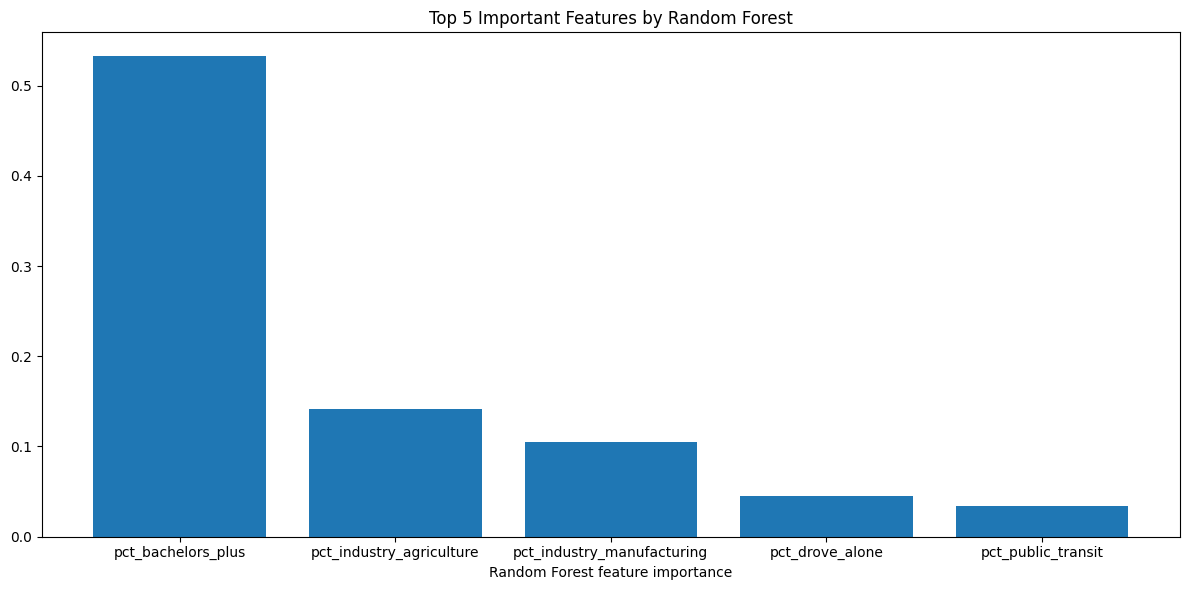

In [6]:
importances = rf_model.feature_importances_
importance_sorted_idx = np.argsort(importances)[::-1]
k = 5
top_k_idx = importance_sorted_idx[:k]
top_k_features = X.columns[top_k_idx]

plt.figure(figsize=(12, 6))
plt.bar(top_k_features, importances[top_k_idx])
plt.xlabel("Random Forest feature importance")
plt.title(f"Top {k} Important Features by Random Forest")
plt.tight_layout()
plt.show()

In [7]:
rf_importance_df = pd.DataFrame({
    "feature": X.columns[importance_sorted_idx],
    "importance": importances[importance_sorted_idx],
})

rf_importance_df.to_csv("data/rf_feature_importance.csv", index=False)

## MLP
Comparing the performance of MLP with linear models, we can see if nonlinear relationships are important for this regression task.

In [8]:
X_train_t = torch.tensor(X_train.to_numpy(), dtype=torch.float32, device=device)
Y_train_t = torch.tensor(Y_train.to_numpy().reshape(-1, 1), dtype=torch.float32, device=device)
X_val_t = torch.tensor(X_val.to_numpy(), dtype=torch.float32, device=device)
Y_val_t = torch.tensor(Y_val.to_numpy().reshape(-1, 1), dtype=torch.float32, device=device)
X_test_t = torch.tensor(X_test.to_numpy(), dtype=torch.float32, device=device)
Y_test_t = torch.tensor(Y_test.to_numpy().reshape(-1, 1), dtype=torch.float32, device=device)

train_ds = TensorDataset(X_train_t, Y_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super(MLP, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, hidden_dim))
        for _ in range(num_layers - 1):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        for layer in self.layers:
            x = nn.ReLU()(layer(x))
        return self.output_layer(x)

def train_mlp(input_dim, hidden_dim, num_layers, lr, epochs):
    model = MLP(input_dim, hidden_dim, num_layers).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    model.train()
    for _ in range(epochs):
        for x, y in train_loader:
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
    
    model.eval()
    with torch.no_grad():
        pred_val = model(X_val_t).squeeze(1).cpu().numpy()
        mse_val = mean_squared_error(Y_val.to_numpy(), pred_val)
        rmse_val = np.sqrt(mse_val)
    return rmse_val

# tune mlp
lr_list = [1e-3, 1e-4, 1e-5]
num_layers_list = [2, 3, 4]
hidden_dim_list = [32, 64, 128, 256]

n_trials = 10

best_params = {
    "lr": 1e-3,
    "hidden_dim": 128,
    "num_layers": 2
}

best_val_rmse = float('inf')
input_dim = X_train.shape[1]
epochs = 100

for trial in range(n_trials):
    lr = random.choice(lr_list)
    hidden_dim = random.choice(hidden_dim_list)
    num_layers = random.choice(num_layers_list)

    rmse_val = train_mlp(input_dim, hidden_dim, num_layers, lr, epochs)

    print(
        f"Trial {trial + 1}/{n_trials}: "
        f"lr={lr}, hidden_dim={hidden_dim}, "
        f"num_layers={num_layers}, val_rmse={rmse_val:.4f}"
    )

    if rmse_val < best_val_rmse:
        best_val_rmse = rmse_val
        best_params = {
            "lr": lr,
            "hidden_dim": hidden_dim,
            "num_layers": num_layers
        }

lr_best = best_params["lr"]
hidden_dim_best = best_params["hidden_dim"]
num_layers_best = best_params["num_layers"]

print(f"Best hyperparameters: lr={lr_best}, hidden_dim={hidden_dim_best}, num_layers={num_layers_best}")
print(f"Best validation RMSE: {best_val_rmse:.4f}")

Trial 1/10: lr=1e-05, hidden_dim=32, num_layers=2, val_rmse=0.0351
Trial 2/10: lr=1e-05, hidden_dim=128, num_layers=2, val_rmse=0.0459
Trial 3/10: lr=0.001, hidden_dim=64, num_layers=4, val_rmse=0.0249
Trial 4/10: lr=0.001, hidden_dim=32, num_layers=4, val_rmse=0.0253
Trial 5/10: lr=0.0001, hidden_dim=32, num_layers=2, val_rmse=0.2380
Trial 6/10: lr=0.001, hidden_dim=64, num_layers=2, val_rmse=4.7487
Trial 7/10: lr=1e-05, hidden_dim=32, num_layers=4, val_rmse=0.0445
Trial 8/10: lr=0.001, hidden_dim=256, num_layers=2, val_rmse=0.0540
Trial 9/10: lr=0.0001, hidden_dim=128, num_layers=2, val_rmse=1.2495
Trial 10/10: lr=0.001, hidden_dim=256, num_layers=3, val_rmse=0.0252
Best hyperparameters: lr=0.001, hidden_dim=64, num_layers=4
Best validation RMSE: 0.0249


In [9]:
# train and test mlp with all selected features on best set of hyperparameters
def train_test_mlp(input_dim, hidden_dim, num_layers, lr, epochs):
    model = MLP(input_dim, hidden_dim, num_layers).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    model.train()
    for _ in range(epochs):
        for x, y in train_loader:
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
    
    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_t).squeeze(1).cpu().numpy()
        mse_test = mean_squared_error(Y_test.to_numpy(), pred_test)
        rmse_test = np.sqrt(mse_test)
        mae_test = mean_absolute_error(Y_test.to_numpy(), pred_test)
    return rmse_test, mae_test

mlp_rmse_test, mlp_mae_test = train_test_mlp(input_dim, hidden_dim_best, num_layers_best, lr_best, epochs)
print(f"MLP Test RMSE: {mlp_rmse_test:.4f}")
print(f"MLP Test MAE: {mlp_mae_test:.4f}")

MLP Test RMSE: 0.0249
MLP Test MAE: 0.0195


In [10]:
# MLP for each feature group
group_names = []
rmse_values = []

# save original all-feature tensors/loaders
train_loader_full = train_loader
X_test_t_full = X_test_t
for group_name, features in feature_groups.items():
    print(f"Train MLP for feature group: {group_name}")
    X_train_group = X_train[features]
    X_test_group = X_test[features]
    X_train_group_t = torch.tensor(X_train_group.to_numpy(), dtype=torch.float32, device=device)
    X_test_group_t = torch.tensor(X_test_group.to_numpy(), dtype=torch.float32, device=device)
    train_group_ds = TensorDataset(X_train_group_t, Y_train_t)
    train_loader = DataLoader(train_group_ds, batch_size=256, shuffle=True)
    X_test_t = X_test_group_t
    test_rmse, test_mae = train_test_mlp(
        input_dim=len(features),
        hidden_dim=hidden_dim_best,
        num_layers=num_layers_best,
        lr=lr_best,
        epochs=epochs
    )
    group_names.append(group_name)
    rmse_values.append(test_rmse)
    print(f"MLP on {group_name}, Test RMSE: {test_rmse:.4f}, Test MAE: {test_mae:.4f}\n")

Train MLP for feature group: occupation
MLP on occupation, Test RMSE: 0.0249, Test MAE: 0.0195

Train MLP for feature group: industry
MLP on industry, Test RMSE: 0.0249, Test MAE: 0.0195

Train MLP for feature group: employment_type
MLP on employment_type, Test RMSE: 0.0249, Test MAE: 0.0195

Train MLP for feature group: education_income
MLP on education_income, Test RMSE: 0.0279, Test MAE: 0.0217

Train MLP for feature group: commute
MLP on commute, Test RMSE: 0.0249, Test MAE: 0.0195

Train MLP for feature group: digital_access
MLP on digital_access, Test RMSE: 0.0249, Test MAE: 0.0195



## Hyperparameter Tuning Approach for MLP

We utilized a random search over a grid search/linear sweep, meaning that instead of evaluating every combination of hyperparameter values, we sampled configurations at random from the same parameter space. This made tuning much cheaper and more efficient.

**Search space explored (10 trials):**

| Hyperparameter | Values sampled from |
|---|---|
| Learning rate | {1e-5, 1e-4, 1e-3} |
| Hidden dimension | {32, 64, 128, 256} |
| Number of layers | {2, 3, 4} |

The best configuration found was `lr=0.001, hidden_dim=64, num_layers=4` (validation RMSE: 0.0249). 

Results varied dramatically across trials, as validation RMSE ranged from 0.0249 to 4.75. A more exhaustive search (e.g., 50–100 trials, or Bayesian optimization) might identify a slightly better configuration, but given that the best MLP already matches the baseline and falls short of linear regression, additional tuning is unlikely to change the substantive conclusions.

## Final model comparisons

In [11]:
model_results_df = pd.DataFrame([
    {
        "model": "Linear Regression",
        "test_rmse": linear_rmse_test,
        "test_mae": linear_mae_test,
    },
    {
        "model": "Lasso alpha=1e-5",
        "test_rmse": lasso_rmse_test,
        "test_mae": lasso_mae_test,
    },
    {
        "model": "Random Forest",
        "test_rmse": rf_rmse_test,
        "test_mae": rf_mae_test,
    },
    {
        "model": "MLP",
        "test_rmse": mlp_rmse_test,
        "test_mae": mlp_mae_test,
    },
])

model_results_df.to_csv("data/model_results.csv", index=False)

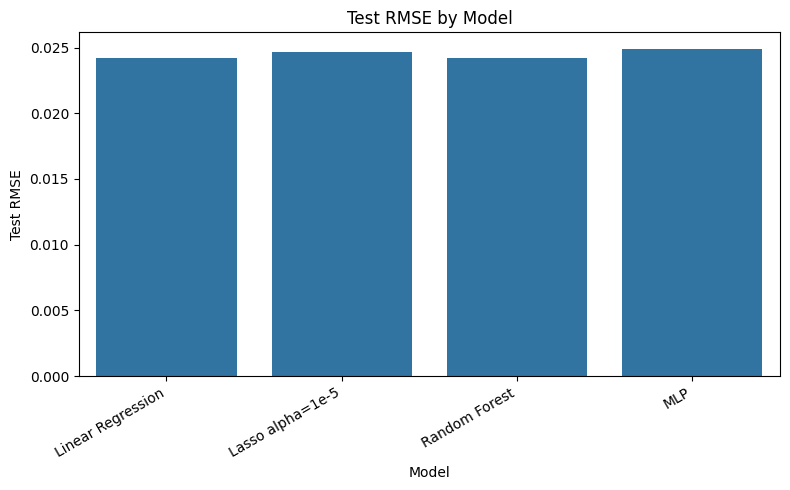

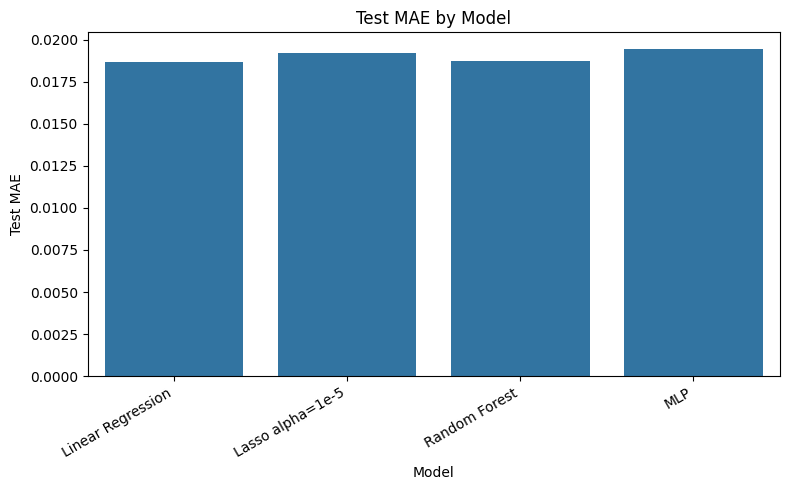

In [12]:
# Plot RMSE
plt.figure(figsize=(8, 5))
sns.barplot(data=model_results_df, x="model", y="test_rmse")
plt.title("Test RMSE by Model")
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Plot MAE
plt.figure(figsize=(8, 5))
sns.barplot(data=model_results_df, x="model", y="test_mae")
plt.title("Test MAE by Model")
plt.xlabel("Model")
plt.ylabel("Test MAE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Overall Takeaways

### What the models tell us

Across all four models tested -- Linear Regression, Lasso, Random Forest, and MLP -- test RMSE converged to a narrow band between 0.0242 and 0.0249. No model substantially outperformed any other, and none made a dramatic improvement over the mean baseline (0.0249). This is because the target is tightly concentrated, so the mean predictor is already strong. The models extract some signal from features, but the gain over baseline is modest.

### What the features tell us

We found that a small number of features appear to carry most of the predictive weight. Lasso at moderate regularization (α = 1e-4) retained only 4 features: `pct_bachelors_plus`, `per_capita_income`, `pct_industry_manufacturing`, and `pct_drove_alone`, while barely changing test RMSE, for example. Random Forest feature importance showed similar results, with `pct_bachelors_plus` receiving the largest importance score. Education and income appear to be the dominant correlates of AI exposure at the census tract level.

However, weaker features may still carry some signal in aggregate. When the MLP was trained on individual feature groups in isolation, most groups (occupation, industry, employment type, commute, digital access) matched the baseline RMSE, so they did not show strong standalone predictive power. But when all features were combined, some full models slightly outperformed the baseline. This suggests that weaker feature groups may encode complementary signal, though the improvement is small and should not be overstated.

### In summary:

Together, the data analysis and modeling notebooks support the following conclusions:

1. AI exposure is correlated with educational attainment and income at the census tract level, consistent with broader research on skill-biased technological change.
2. The tested nonlinear model does not improve over simpler models, suggesting that linear relationships explain much of the available predictive signal in this setup.
3. Demographic features from the ACS provide a modest proxy for AI exposure when direct measurement is unavailable, with prediction error around ±0.024 on a 0-0.29 scale.
4. Feature categories beyond education/income (industry mix, commute patterns, digital access) may add marginal signal when combined, but their contribution appears limited.

## Model Limitations & Potential Biases

Several structural characteristics of this dataset constrain how much any model can improve over a simple baseline.

First, the target distribution is well-behaved. AI exposure scores follow a near-Gaussian distribution tightly concentrated around the mean, with limited variance across census tracts. This means a mean predictor is already a reasonable guess for most observations, and any supervised model is competing against a strong naive benchmark.

All models we tested were relatively shallow. We trained linear regression, Lasso regression, a shallow Random Forest (max depth 5, 10 trees), and a small MLP (4 layers, 64 hidden units). Deeper or more expressive models were not explored. For a dataset of this size and feature count, this is a reasonable tradeoff, but it means we cannot fully rule out that a more expressive model would find additional signal. The fact that the tested MLP did not outperform linear models suggests that this setup did not find strong nonlinear predictive structure, though it does not fully rule out nonlinear relationships.

Regarding data quality, the demographic features come from the American Community Survey (ACS), which may contain known and unknown biases, including undercounting of certain populations, sampling error in small tracts, and the use of 5-year estimates that may not reflect current conditions when the AI exposure metric was calculated. Census tracts with small working populations may also have noisier occupation and industry percentages, potentially inflating or deflating predicted exposure.

Finally, we note that all associations identified here are observational. A high `pct_bachelors_plus` does not cause higher AI exposure; both may be driven by underlying economic geography, such as urban knowledge-economy clusters. Predictions from this model should be interpreted as demographic correlates of AI exposure, not causal mechanisms.